## Method One: Holdout Method
- hold out some instances for testing
- common ratios: 70-30, 75-25, 90-10

In [134]:
import pandas as pd
df = pd.read_csv("shirt_sizes_long.csv")
print(df.head())

X = df.drop(["t-shirt size"], axis="columns")
y = df["t-shirt size"]
print(X.head())
print(y.head())

   height(cm)  weight(kg) t-shirt size
0         158          58            M
1         158          59            M
2         158          63            M
3         160          59            M
4         160          60            M
   height(cm)  weight(kg)
0         158          58
1         158          59
2         158          63
3         160          59
4         160          60
0    M
1    M
2    M
3    M
4    M
Name: t-shirt size, dtype: object


In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(X_train)
print(y_train)
print(len(X_train))
print(len(X_test))

    height(cm)  weight(kg)
6          163          61
12         168          62
15         170          63
14         168          66
8          163          64
1          158          59
7          160          64
3          160          59
2          158          63
16         170          64
10         165          62
4          160          60
17         170          68
13         168          63
6     M
12    L
15    L
14    L
8     L
1     M
7     L
3     M
2     M
16    L
10    L
4     M
17    L
13    L
Name: t-shirt size, dtype: object
14
4


In [136]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print(X_test)

[[0.41666667 0.22222222]
 [0.83333333 0.33333333]
 [1.         0.44444444]
 [0.83333333 0.77777778]
 [0.41666667 0.55555556]
 [0.         0.        ]
 [0.16666667 0.55555556]
 [0.16666667 0.        ]
 [0.         0.44444444]
 [1.         0.55555556]
 [0.58333333 0.33333333]
 [0.16666667 0.11111111]
 [1.         1.        ]
 [0.83333333 0.44444444]]
[[ 0.58333333  0.66666667]
 [ 0.58333333  0.22222222]
 [ 0.         -0.11111111]
 [ 0.41666667  0.11111111]]


In [137]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors = 3, metric="euclidean")
knn_clf.fit(X_train, y_train)
y_predicted = knn_clf.predict(X_test)
print(y_predicted)

['L' 'L' 'M' 'M']


In [138]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_predicted)
print(acc)

1.0


[[2 0]
 [0 2]]


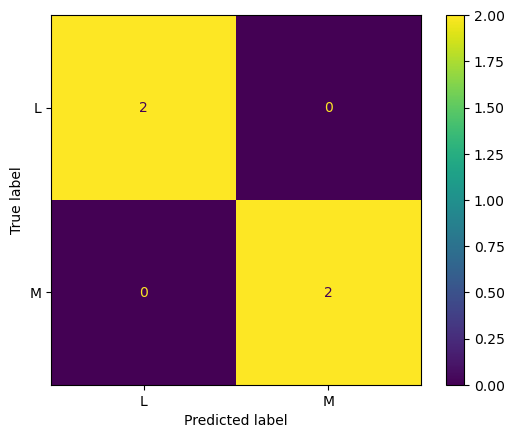

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predicted)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_clf.classes_)
disp.plot()

tree acc = 0.75, knn acc = 1.0


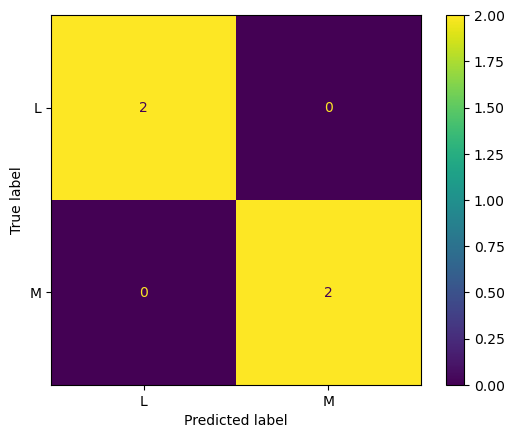

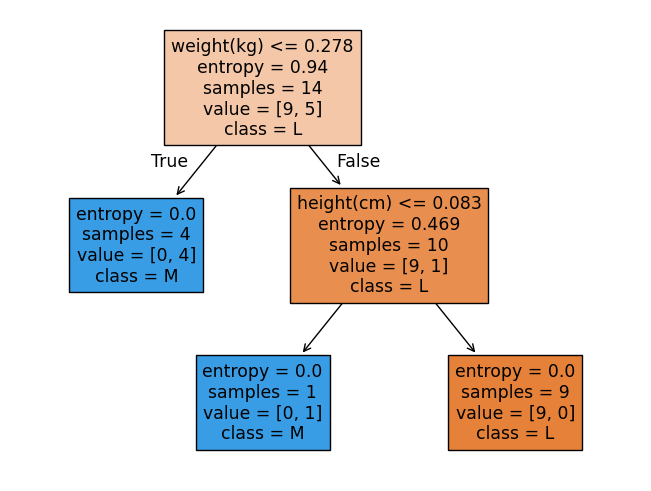

In [140]:
# task: Decision Tree Classifier
# using our X_train, y_train, X_test, y_test
# get the accuracy of the tree and the confusion matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


tree_clf = DecisionTreeClassifier(criterion="entropy")
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

tree_acc = accuracy_score(y_test, y_pred_tree)
print(f"tree acc = {tree_acc}, knn acc = {acc}")

tree_cm = confusion_matrix(y_test,y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=tree_cm, display_labels=tree_clf.classes_)
disp.plot()

plt.figure(layout="constrained")
plot_tree(tree_clf, feature_names=X.columns, class_names=tree_clf.classes_, filled=True)

plt.show()